In [8]:
import mlflow
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

mlflow.set_tracking_uri("file:///app/experiments/mlruns")
# Cargar todos los runs
runs = mlflow.search_runs(
    experiment_names=['baseline-none', 'baseline-ben-graham', 'filter-experiments']
)

In [14]:
# Mostrar comparación
runs_comparison = runs[[
    'run_id', 
    'params.filter_name',
    'params.epochs',
    'metrics.train_accuracy',
    'metrics.val_accuracy',
    'metrics.val_recall'
]].sort_values('metrics.val_recall', ascending=False)

runs_comparison

,run_id,params.filter_name,params.epochs,metrics.train_accuracy,metrics.val_accuracy,metrics.val_recall
6,07d403f5d7b34302b1d233bfba4505ad,none,30,0.781771,0.801562,0.849817
0,0769e88029784607bff6aec7758bf466,gaussian_clahe,30,0.788542,0.782812,0.846189
3,8009a8cf1cce42d0881422521f2372af,gaussian,30,0.809896,0.782812,0.840703
4,a7eafba10a2847a69ec9a6daa33c7dde,clahe,30,0.794792,0.770312,0.832797
1,80d819bbf07143a8bb8320f1ff5f3f39,clahe_ben_graham,30,0.730729,0.737500,0.814790
5,afcc4f567ece4c6c9b37447b4a863de3,ben_graham,30,0.745833,0.734375,0.810070
2,200793e0f263437cac0f5b1d72ba7b81,sobel,30,0.742188,0.784375,0.786827


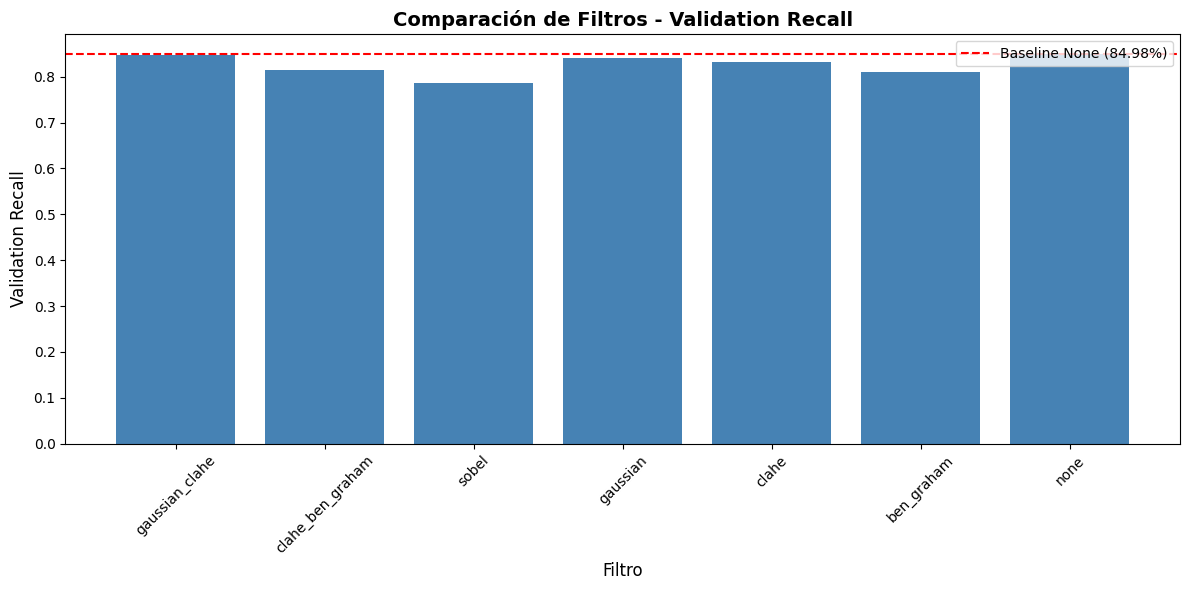

In [16]:
# Gráfica de barras
fig, ax = plt.subplots(figsize=(12, 6))

filters = runs['params.filter_name'].values
val_acc = runs['metrics.val_recall'].values

ax.bar(filters, val_acc, color='steelblue')
ax.axhline(y=0.849817, color='r', linestyle='--', label='Baseline None (84.98%)')
ax.set_xlabel('Filtro', fontsize=12)
ax.set_ylabel('Validation Recall', fontsize=12)
ax.set_title('Comparación de Filtros - Validation Recall', fontsize=14, fontweight='bold')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()